In [77]:
import pandas as pd
from sklearn.preprocessing import OrdinalEncoder
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score
from edupredict.preprocessing import encode_features, make_pipeline, TARGET
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score


df = pd.read_csv("../data/dataset.csv")
df.shape

(6607, 20)

## Data cleaning & Splitting & Scalling

### Replace the missing data

In [49]:
def impute_by_mode(columns=['Teacher_Quality', 'Parental_Education_Level', 'Distance_from_Home']):
    for col in columns:
        df[col] = df[col].fillna(df[col].mode()[0])
impute_by_mode()

In [50]:
df.duplicated().sum()

np.int64(0)

### Dropped records with invalid `Exam_Score`

In [51]:
df = df[~((df['Exam_Score'] > 100) | (df['Exam_Score'] < 0))]

### Outliers

In [52]:
q1 = df['Exam_Score'].quantile(0.25)
q3 = df['Exam_Score'].quantile(0.75)
iqr = q3 - q1
x = iqr * 1.5

lower_bound = q1 - x
upper_bound = q3 + x

print(lower_bound, upper_bound)

59.0 75.0


#### Removed them

In [53]:
df = df[(df['Exam_Score'] >= lower_bound) & (df['Exam_Score'] <= upper_bound)]

### Encode categorical columns

In [54]:
df = encode_features(df)

### Save the clean encoded df

In [55]:
df.to_csv('../data/cleaned_data.csv')

In [56]:
# plt.figure(figsize=(12, 10))
# sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)
# plt.title("Correlation matrix (post-encoding)")
# plt.show()

### Train/Test split

In [57]:
X = df.drop(columns=TARGET)
y = df[TARGET]

In [58]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

## Baseline Model Training

In [59]:
def evaluate(model, X, y):
    y_pred = model.predict(X)
    return {
        "RMSE": root_mean_squared_error(y, y_pred),
        "MAE": mean_absolute_error(y, y_pred),
        "R2": r2_score(y, y_pred),
    }

In [60]:
pipe_lr = make_pipeline(LinearRegression())
pipe_rf = make_pipeline(RandomForestRegressor(random_state=42))
pipe_svr = make_pipeline(SVR())

In [62]:
results = []
for name, pipe in [("LinearRegression", pipe_lr), ("RandomForest", pipe_rf), ("SVR", pipe_svr)]:
    pipe.fit(X_train, y_train)
    metrics = evaluate(pipe, X_test, y_test)
    results.append({"Model": name, **metrics})

results_df = pd.DataFrame(results)
results_df
results_df.to_csv("../reports/baseline_results.csv", index=False)

## Grid Search

In [63]:
param_grid_lr = {
    "model__fit_intercept": [True, False],
    "model__positive": [True, False],
}

param_grid_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__min_samples_split": [2, 5, 10],
}

param_grid_svr = {
    "model__C": [0.1, 1, 10],
    "model__kernel": ["linear", "rbf"],
    "model__epsilon": [0.01, 0.1, 0.5],
}

In [66]:
grid_lr = GridSearchCV(pipe_lr, param_grid_lr, cv=3, scoring="r2")
grid_lr.fit(X_train, y_train)
print(grid_lr.best_params_, grid_lr.best_score_)

{'model__fit_intercept': True, 'model__positive': False} 0.9898042871787759


In [67]:
grid_rf = GridSearchCV(pipe_rf, param_grid_rf, cv=3, scoring="r2", n_jobs=-1)
grid_rf.fit(X_train, y_train)
print(grid_rf.best_params_, grid_rf.best_score_)

{'model__max_depth': None, 'model__min_samples_split': 2, 'model__n_estimators': 300} 0.8827766827378385


In [68]:
grid_svr = GridSearchCV(pipe_svr, param_grid_svr, cv=3, scoring="r2")
grid_svr.fit(X_train, y_train)
print(grid_svr.best_params_, grid_svr.best_score_)

{'model__C': 1, 'model__epsilon': 0.5, 'model__kernel': 'linear'} 0.9898336642347484


In [69]:
best_lr = grid_lr.best_estimator_
best_rf = grid_rf.best_estimator_
best_svr = grid_svr.best_estimator_

### Comparing the tuned ones

In [70]:
tuned_results = []
for name, pipe in [("LinearRegression", best_lr), ("RandomForest", best_rf), ("SVR", best_svr)]:
    metrics = evaluate(pipe, X_test, y_test)
    tuned_results.append({"Model": name, **metrics})

tuned_results_df = pd.DataFrame(tuned_results)
tuned_results_df

,Model,RMSE,MAE,R2
0,LinearRegression,0.327058,0.271589,0.989723
1,RandomForest,1.057592,0.839349,0.892535
2,SVR,0.326414,0.270939,0.989763


### based vs tuned models

In [71]:
comparison_df = results_df.merge(
    tuned_results_df, on="Model", suffixes=("_baseline", "_tuned")
)
comparison_df

,Model,RMSE_baseline,MAE_baseline,R2_baseline,RMSE_tuned,MAE_tuned,R2_tuned
0,LinearRegression,0.327058,0.271589,0.989723,0.327058,0.271589,0.989723
1,RandomForest,1.063822,0.842006,0.891265,1.057592,0.839349,0.892535
2,SVR,0.459213,0.358146,0.979739,0.326414,0.270939,0.989763


### Before/after tuning comparison

Linear Regression scores exactly the same before and after tuning (RMSE = 0.327, R² = 0.990). GridSearchCV tested fit_intercept and positive, and the default values turned out to be optimal, confirming that the model already captures the near-linear relationship between the features and Exam_Score very well.

Random Forest improves slightly (RMSE: 1.064 → 1.058, R²: 0.891 → 0.893). The gain is limited because this model builds its predictions from decision thresholds (step-like splits), a structure that's inherently less suited to approximating a linear relationship, regardless of hyperparameters.

SVR improves substantially (RMSE: 0.459 → 0.326, R²: 0.980 → 0.990), nearly matching Linear Regression's performance. The default kernel (rbf, non-linear) wasn't well suited to this data; the search grid included a linear kernel option, which GridSearchCV likely selected, explaining this jump.

Overall, tuning had a different effect depending on each model's structure: no effect on a model that was already well suited to the data, a limited effect on a model structurally constrained by its splits, and a decisive effect on a model whose default parameter didn't match the problem.

### Plots (visualization)

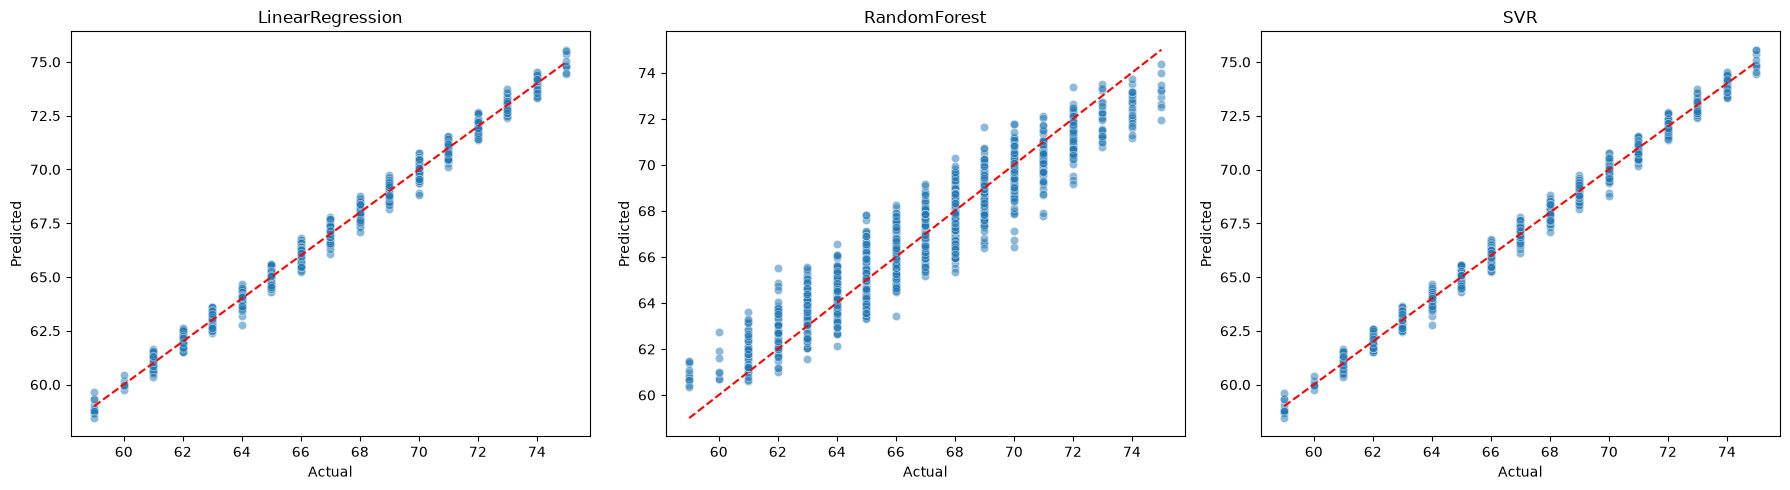

In [72]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pipe) in zip(axes, [("LinearRegression", best_lr), ("RandomForest", best_rf), ("SVR", best_svr)]):
    y_pred = pipe.predict(X_test)
    sns.scatterplot(x=y_test, y=y_pred, ax=ax, alpha=0.5)
    ax.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "r--")
    ax.set_title(name)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

plt.tight_layout()
plt.show()

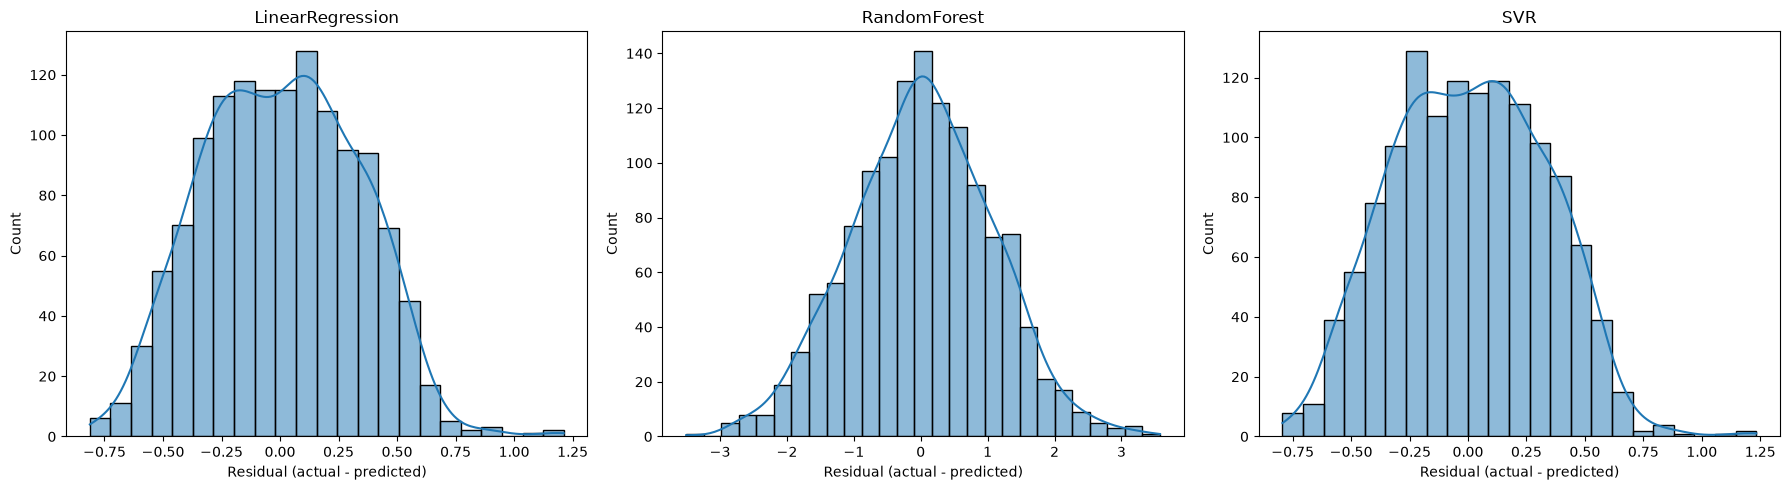

In [73]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (name, pipe) in zip(axes, [("LinearRegression", best_lr), ("RandomForest", best_rf), ("SVR", best_svr)]):
    residuals = y_test - pipe.predict(X_test)
    sns.histplot(residuals, kde=True, ax=ax)
    ax.set_title(name)
    ax.set_xlabel("Residual (actual - predicted)")

plt.tight_layout()
plt.show()

### Save the summary table (baseline and tuned)

In [74]:
comparison_df.to_csv("../reports/summary_table.csv", index=False)
comparison_df

,Model,RMSE_baseline,MAE_baseline,R2_baseline,RMSE_tuned,MAE_tuned,R2_tuned
0,LinearRegression,0.327058,0.271589,0.989723,0.327058,0.271589,0.989723
1,RandomForest,1.063822,0.842006,0.891265,1.057592,0.839349,0.892535
2,SVR,0.459213,0.358146,0.979739,0.326414,0.270939,0.989763


### Robustness

In [75]:
for name, pipe in [("LinearRegression", best_lr), ("RandomForest", best_rf), ("SVR", best_svr)]:
    residuals = y_test - pipe.predict(X_test)
    print(name, "residual std:", residuals.std())

LinearRegression residual std: 0.32712703224599643
RandomForest residual std: 1.0578521563046057
SVR residual std: 0.326453893417028


In [ ]:
for name, pipe in [("LinearRegression", best_lr), ("RandomForest", best_rf), ("SVR", best_svr)]:
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="r2")
    print(name, "CV R² mean:", scores.mean(), "CV R² std:", scores.std())

LinearRegression CV R² mean: 0.9898069872547609 CV R² std: 0.0004039546133672809
RandomForest CV R² mean: 0.8872418649876735 CV R² std: 0.005961179888050023
SVR CV R² mean: 0.9898047929092437 CV R² std: 0.0003956572893324205


### Choosing the final model

`Linear Regression` and `SVR` perform almost identically across every metric measured: RMSE, MAE, R², residual standard deviation, and cross-validation R² standard deviation. Both clearly outperform Random Forest, which shows higher errors and less stability across folds.

Since `Linear Regression` matches `SVR`'s performance **without needing any tuning**, and its coefficients are directly interpretable, unlike `SVR`, **it is selected as the final model**. It offers the best combination of accuracy, robustness, and simplicity for this dataset.

In [78]:
final_model = best_lr
final_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](26,)","['Hours_Studied','Attendance','Parental_Involvement',..., 'Peer_Influence_Negative','Peer_Influence_Neutral', 'Peer_Influence_Positive']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,26
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('scale', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be

## Export the pipeline

In [79]:
import joblib

joblib.dump(final_model, "../models/final_pipeline.joblib", compress=3)

['../models/final_pipeline.joblib']

## Save the ordered list of expected columns

In [80]:
import json

expected_columns = list(X_train.columns)

with open("../models/expected_columns.json", "w") as f:
    json.dump(expected_columns, f)